In [10]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
url = "https://people.dbmi.columbia.edu/~friedma/Projects/DiseaseSymptomKB/index.html"

response = requests.get(url)
soup = BeautifulSoup(response.text, 'lxml')

# Extract the main disease-symptom table
table = soup.find_all('table')[0]

rows = []
for tr in table.find_all('tr'):
    cols = [td.text.strip() for td in tr.find_all('td')]
    if len(cols) == 3:
        rows.append(cols)

df = pd.DataFrame(rows, columns=['Disease', 'Symptom', 'Frequency'])
df.head()


,Disease,Symptom,Frequency
0,Disease,Count of Disease\n Occurrence,Symptom
1,UMLS:C0020538_hypertensive\n disease,3363,UMLS:C0008031_pain\n chest
2,,,UMLS:C0392680_shortness\n of breath
3,,,UMLS:C0012833_dizziness
4,,,UMLS:C0004093_asthenia


In [17]:
df.drop_duplicates(inplace=True)
df = df[df['Disease'] != '']  # remove empty rows
df['Symptom'] = df['Symptom'].str.lower().str.strip()
df['Disease'] = df['Disease'].str.strip()
df.head()

,Disease,Symptom,Frequency
0,Disease,count of disease\n occurrence,1.0
1,UMLS:C0020538_hypertensive\n disease,3363,1.0
2,NaN,NaN,1.0
13,UMLS:C0011847_diabetes,1421,1.0
22,UMLS:C0011570_depression\n mental^UMLS:C00115...,1337,1.0


In [14]:

save_path = '/content/drive/MyDrive/Applied_ML_CU/data_fatch_EDA_saved.csv'

df.to_csv(save_path, index=False)
print(f"File saved to: {save_path}")


File saved to: /content/drive/MyDrive/Applied_ML_CU/data_fatch_EDA_saved.csv


In [15]:
df = pd.read_csv('/content/drive/MyDrive/Applied_ML_CU/data_fatch_EDA_saved.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


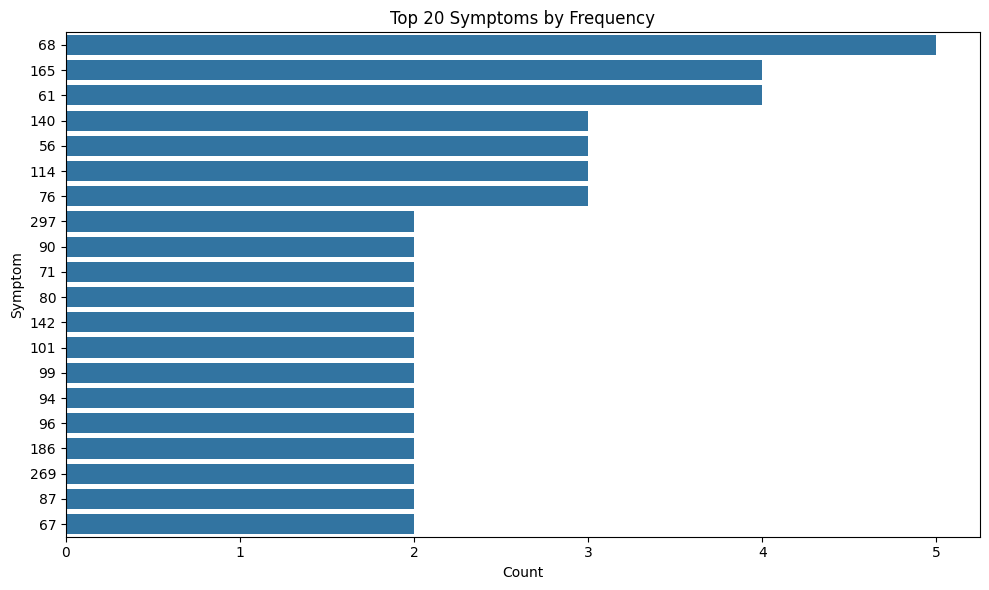

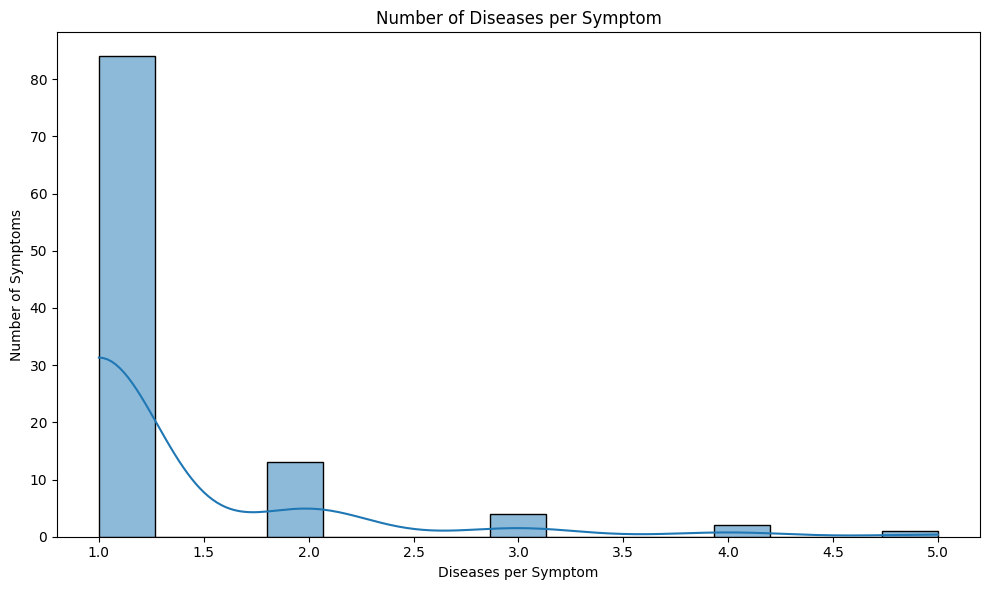

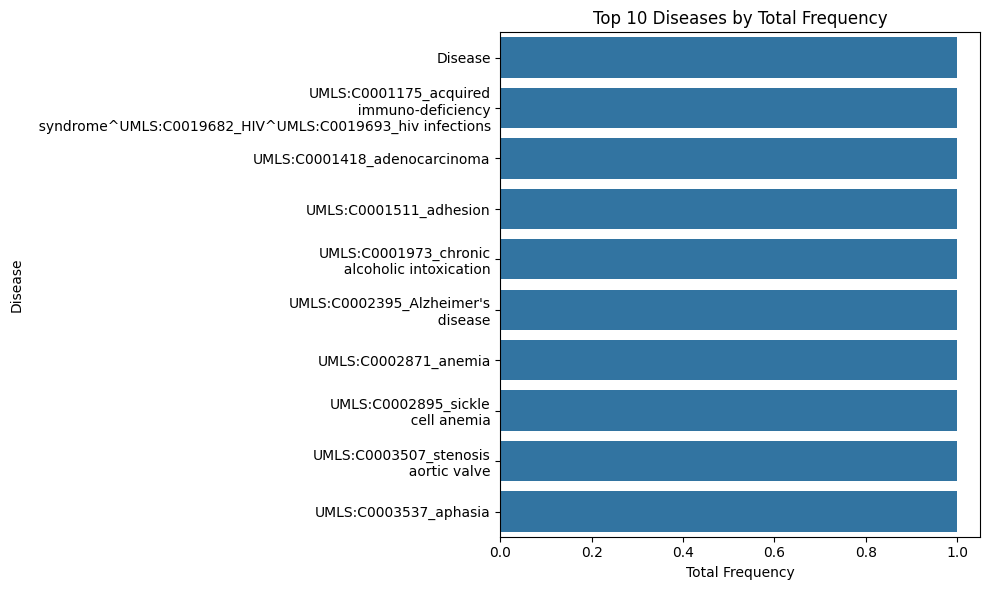

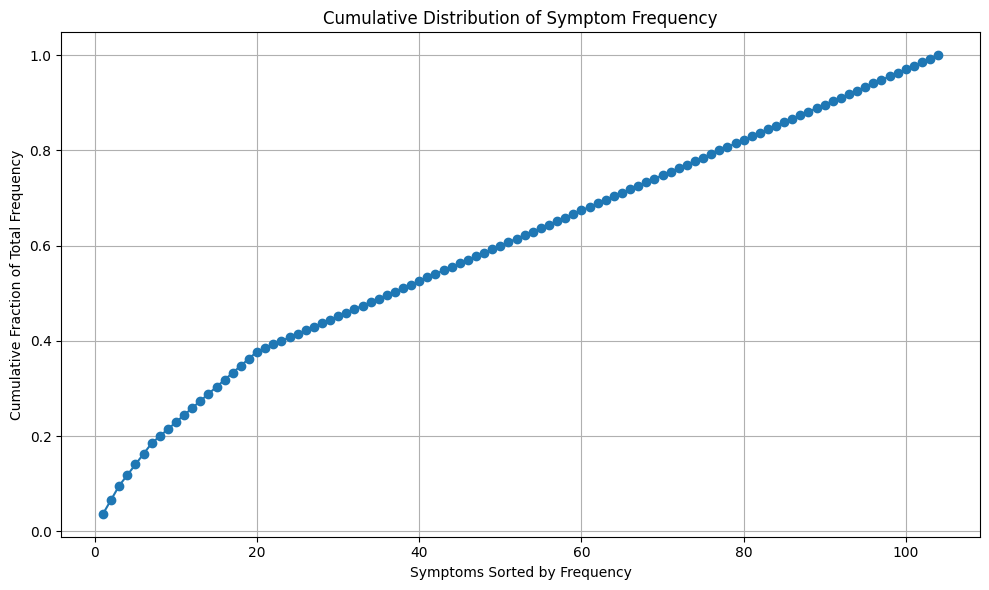

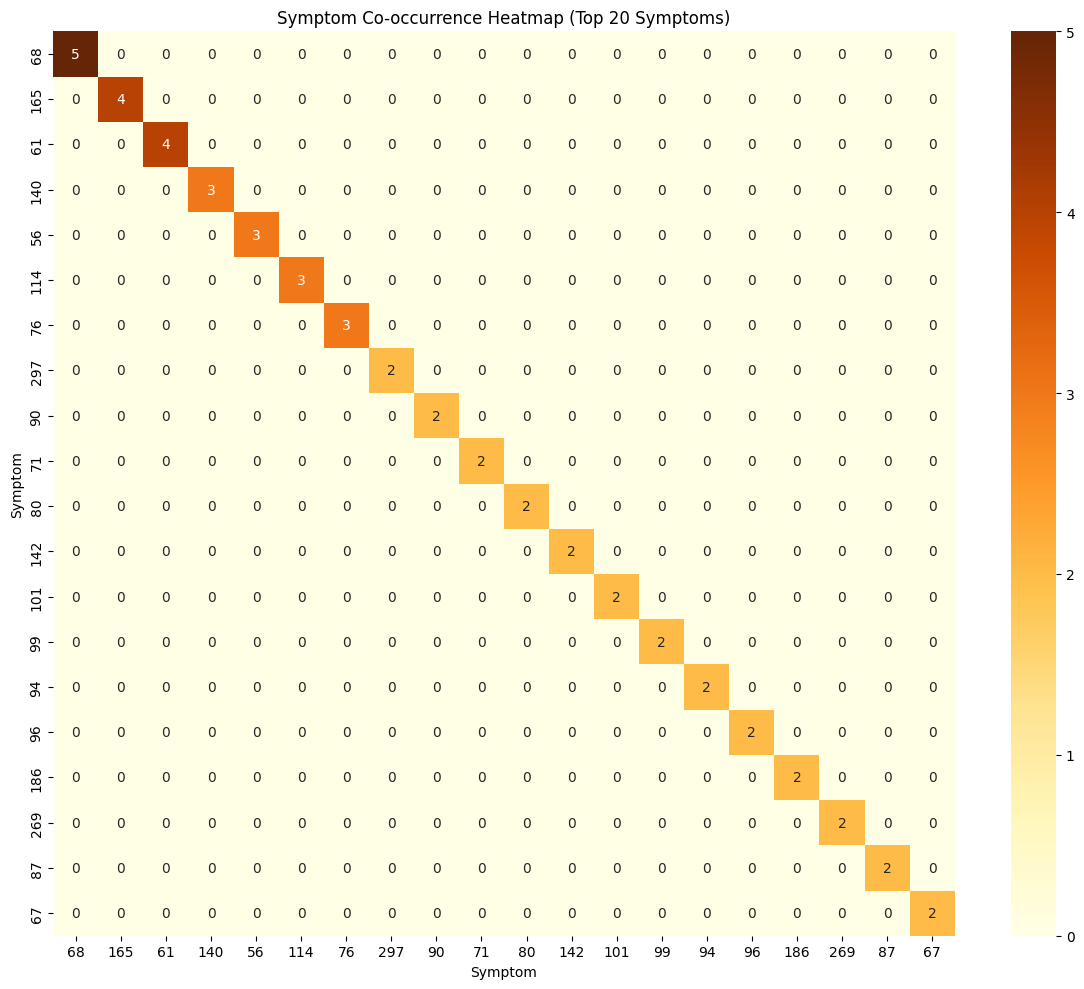


All 6 figures saved and displayed from: /content/drive/MyDrive/EDA_All_Figures


In [19]:
# -------------------------------
# Setup and Imports
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from google.colab import drive
drive.mount('/content/drive')

# -------------------------------
# Load Dataset from Drive
# -------------------------------
file_path = "/content/drive/MyDrive/Applied_ML_CU/data_fatch_EDA_saved.csv"
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# Clean data
df['Disease'] = df['Disease'].str.strip()
df['Symptom'] = df['Symptom'].str.strip()
if 'Frequency' not in df.columns:
    df['Frequency'] = 1
df['Frequency'] = pd.to_numeric(df['Frequency'], errors='coerce').fillna(1)

# Create folder for figures
output_folder = "/content/drive/MyDrive/EDA_All_Figures"
os.makedirs(output_folder, exist_ok=True)

# -------------------------------
# 1. Top 20 Symptoms by Frequency
# -------------------------------
symptom_counts = df['Symptom'].value_counts()
top_symptoms = symptom_counts.head(20)

plt.figure(figsize=(10,6))
sns.barplot(y=top_symptoms.index, x=top_symptoms.values)
plt.title("Top 20 Symptoms by Frequency")
plt.xlabel("Count")
plt.ylabel("Symptom")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "top20_symptoms.png"))
plt.show()

# -------------------------------
# 2. Disease vs Symptom Heatmap (Top 20 each)
# -------------------------------
top_diseases = df['Disease'].value_counts().head(20).index
subset = df[df['Disease'].isin(top_diseases) & df['Symptom'].isin(top_symptoms.index)]

if not subset.empty:
    pivot = subset.groupby(['Disease', 'Symptom']).size().unstack(fill_value=0)
    plt.figure(figsize=(12,10))
    sns.heatmap(pivot, cmap="YlGnBu", annot=True, fmt="d")
    plt.title("Disease vs Symptom Heatmap (Top 20)")
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "disease_symptom_heatmap.png"))
    plt.show()

else:
    print("Warning: No overlapping records found for top diseases and top symptoms.")



# -------------------------------
# 3. Number of Diseases per Symptom
# -------------------------------
diseases_per_symptom = df.groupby('Symptom')['Disease'].count()
plt.figure(figsize=(10,6))
sns.histplot(diseases_per_symptom, bins=15, kde=True)
plt.title("Number of Diseases per Symptom")
plt.xlabel("Diseases per Symptom")
plt.ylabel("Number of Symptoms")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "diseases_per_symptom.png"))
plt.show()

# -------------------------------
# 4. Top 10 Diseases by Total Frequency
# -------------------------------
disease_freq_sum = df.groupby('Disease')['Frequency'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(y=disease_freq_sum.index, x=disease_freq_sum.values)
plt.title("Top 10 Diseases by Total Frequency")
plt.xlabel("Total Frequency")
plt.ylabel("Disease")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "top10_diseases_by_frequency.png"))
plt.show()

# -------------------------------
# 5. Cumulative Distribution of Symptom Frequency
# -------------------------------
symptom_freq = df.groupby('Symptom')['Frequency'].sum().sort_values(ascending=False)
cumulative = symptom_freq.cumsum() / symptom_freq.sum()

plt.figure(figsize=(10,6))
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o')
plt.title("Cumulative Distribution of Symptom Frequency")
plt.xlabel("Symptoms Sorted by Frequency")
plt.ylabel("Cumulative Fraction of Total Frequency")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "cumulative_symptom_freq.png"))
plt.show()

# -------------------------------
# 6. Symptom Co-occurrence Heatmap (Top 20 Symptoms)
# -------------------------------
co_matrix = pd.DataFrame(0, index=top_symptoms.index, columns=top_symptoms.index)
for disease in df['Disease'].unique():
    symptoms = df[df['Disease'] == disease]['Symptom'].values
    symptoms = [s for s in symptoms if s in top_symptoms.index]
    for i in range(len(symptoms)):
        for j in range(i, len(symptoms)):
            co_matrix.loc[symptoms[i], symptoms[j]] += 1
            if i != j:
                co_matrix.loc[symptoms[j], symptoms[i]] += 1

plt.figure(figsize=(12,10))
sns.heatmap(co_matrix, annot=True, cmap="YlOrBr", fmt="d")
plt.title("Symptom Co-occurrence Heatmap (Top 20 Symptoms)")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "symptom_cooccurrence_heatmap.png"))
plt.show()

print(f"\nAll 6 figures saved and displayed from: {output_folder}")
